In [ ]:
import pandas as pd
import numpy as np

<h2>Load Dataset</h2>

In [ ]:
df = pd.read_csv("car_data.csv")

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


<h2>Feature Engineering</h2>

In [ ]:
df['Car_Age'] = 2026 - df['Year']
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()
df['Brand']

0       ritz
1        sx4
2       ciaz
3      wagon
4      swift
       ...  
296     city
297     brio
298     city
299     city
300     brio
Name: Brand, Length: 301, dtype: object

In [ ]:
#Calculate Goodwill feature

#Step 1 - Make a new feature called Brand
brand_stats = df.groupby('Brand').agg(
    Avg_Present_Price = ('Present_Price', 'mean'),
    Num_Cars          = ('Car_Name', 'count'),
    Avg_Age           = ('Car_Age', 'mean'),
    Avg_Kms           = ('Driven_kms', 'mean')
).round(2)

#Step 2 - calculate necessary items
brand_stats['Score_Price']      = brand_stats['Avg_Present_Price']
brand_stats['Score_Popularity'] = brand_stats['Num_Cars']
brand_stats['Score_Usage']      = brand_stats['Avg_Kms']

#Step 3 - Finally get Goodwill feature
brand_stats['Goodwill_Score'] = (
    0.5 * brand_stats['Score_Price'] +
    0.3 * brand_stats['Score_Popularity'] +
    0.2 * brand_stats['Score_Usage']
).round(4)

df['Brand_Goodwill_Score'] = df['Brand'].map(brand_stats['Goodwill_Score'])

print(brand_stats[['Goodwill_Score']].sort_values('Goodwill_Score', ascending=False))

          Goodwill_Score
Brand                   
activa         33454.494
camry          28412.165
800            25401.440
land           15646.600
fortuner       12559.229
corolla        11823.805
innova         11754.247
dzire          10853.715
sx4            10153.835
omni           10001.645
ritz            9862.420
etios           9563.315
verna           8558.323
creta           8448.034
wagon           8132.375
i10             7953.865
city            7873.079
ertiga          7491.544
amaze           7066.123
mahindra        7001.000
i20             6979.705
swift           6916.190
s               6690.405
honda           6676.068
hero            6387.481
alto            5795.090
elantra         5651.495
ciaz            5592.824
xcent           5494.131
brio            4953.180
baleno          4909.035
grand           4752.726
bajaj           4697.794
jazz            4521.408
eon             4331.700
yamaha          4290.320
tvs             3947.755
royal           3342.355


In [ ]:
#Calculate Mileage feature from Driven_kms and Car_Age columns

df['Mileage_per_year'] = df['Driven_kms']/df['Car_Age'].replace(0,np.nan)
df['Mileage_per_year'] = df['Mileage_per_year'].fillna(df['Driven_kms'])
df['Mileage_per_year'] = pd.to_numeric(df['Mileage_per_year'].round(2))

In [ ]:
#Calculate Horsepower feature by taking Selling_Price as proxy

HP_MIN, HP_MAX = 60, 300

p_min = df['Present_Price'].min()
p_max = df['Present_Price'].max()

df['Horsepower'] = (
    (df['Present_Price'] - p_min) / (p_max - p_min)
    * (HP_MAX - HP_MIN)
    + HP_MIN
).round(1)

print(df[['Car_Name', 'Present_Price', 'Horsepower']].head(10))

        Car_Name  Present_Price  Horsepower
0           ritz           5.59        73.7
1            sx4           9.54        84.0
2           ciaz           9.85        84.8
3        wagon r           4.15        70.0
4          swift           6.87        77.0
5  vitara brezza           9.83        84.7
6           ciaz           8.12        80.3
7        s cross           8.61        81.6
8           ciaz           8.89        82.3
9           ciaz           8.92        82.4


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand,Brand_Goodwill_Score,Mileage_per_year,Horsepower
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz,9862.420,2250.00,73.7
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4,10153.835,3307.69,84.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz,5592.824,766.67,84.8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon,8132.375,346.67,70.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift,6916.190,3537.50,77.0


In [ ]:
#Store above features in df1

df1 = df[['Mileage_per_year','Horsepower','Brand_Goodwill_Score','Selling_Price']].copy()
df1.head()

,Mileage_per_year,Horsepower,Brand_Goodwill_Score,Selling_Price
0,2250.00,73.7,9862.420,3.35
1,3307.69,84.0,10153.835,4.75
2,766.67,84.8,5592.824,7.25
3,346.67,70.0,8132.375,2.85
4,3537.50,77.0,6916.190,4.60


In [ ]:
df1.shape

(301, 4)

<h2>Data Cleaning</h2>

In [ ]:
#Checking for null values

df1.isnull().sum()

Mileage_per_year        0
Horsepower              0
Brand_Goodwill_Score    0
Selling_Price           0
dtype: int64

In [ ]:
#Checking for duplicate values

df1.duplicated().sum()

np.int64(2)

In [ ]:
#Remove Duplicates

df1 = df1.drop_duplicates().copy()

In [ ]:
df1.describe()

,Mileage_per_year,Horsepower,Brand_Goodwill_Score,Selling_Price
count,299.000000,299.000000,299.000000,299.000000
mean,2785.223411,78.777258,7379.426682,4.589632
std,2288.319462,22.280342,4153.756056,4.984240
min,50.000000,60.000000,281.210000,0.100000
25%,1375.000000,62.300000,4697.794000,0.850000
50%,2538.460000,75.000000,6676.068000,3.510000
75%,3679.560000,84.750000,8558.323000,6.000000
max,27777.780000,300.000000,33454.494000,35.000000


<h2>Data Preprocessing</h2>

In [ ]:
#Normalise Features using Min Max Scaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
FEATURES = ['Mileage_per_year', 'Horsepower', 'Brand_Goodwill_Score']

X_raw = df1[FEATURES]
y     = df1['Selling_Price']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# Then fit scaler ONLY on train, transform both
scaler  = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=FEATURES)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=FEATURES)

<h2>Visualising Data</h2>

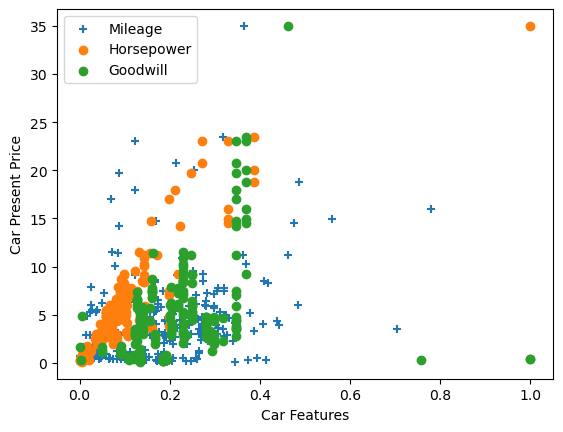

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def scatter_plot(X_train,y):
    plt.scatter(X_train['Mileage_per_year'],y,marker='+',label='Mileage')
    plt.scatter(X_train['Horsepower'],y,label='Horsepower')
    plt.scatter(X_train['Brand_Goodwill_Score'],y,marker='o',label='Goodwill')
    plt.xlabel('Car Features')
    plt.ylabel('Car Present Price')
    plt.legend()
    plt.show()

scatter_plot(X_train,y_train)

<h2>Remove Outliers using Z score</h2>

In [ ]:
def zscore_mask(series, threshold=3):
    """Flag rows where |z| > threshold as outliers."""
    z_scores = (series - series.mean()) / series.std()
    return z_scores.abs() <= threshold

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

mask_z = pd.Series([True] * len(X_train), index=X_train.index)
for col in FEATURES:
    mask_z = mask_z & zscore_mask(X_train[col])

In [ ]:
X_clean = X_train[mask_z]
y_clean = y_train[mask_z]

<h2>Clean Data Visualisation</h2>

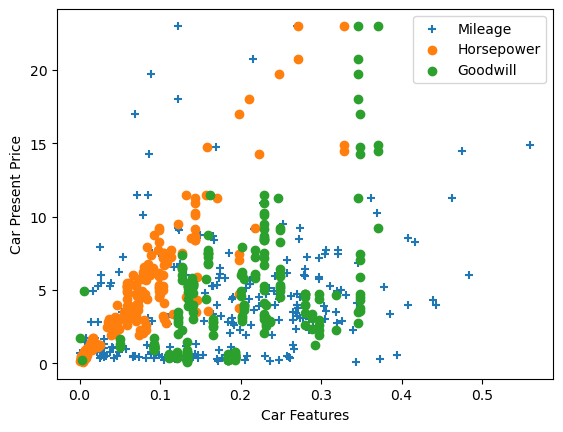

In [ ]:
scatter_plot(X_clean,y_clean)

<h2>Model Building</h2>

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(LinearRegression(),X_clean,y_clean,cv=5)

array([0.74717114, 0.78340159, 0.80267759, 0.86927791, 0.85512246])

In [ ]:
#Training the model using train data

model = LinearRegression()
model.fit(X_clean,y_clean)

LinearRegression()

In [ ]:
#Making predictions

y_pred = model.predict(X_test)

In [ ]:
#Calculating accuracy of model
score = model.score(X_test, y_test)

print(f"Accuracy of model = {score}")

Accuracy of model = 0.5294841085468329


<h2>Model Evaluation</h2>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error = {mae}")
print(f"Mean Squared Error = {mse}")
print(f"R-squared Error = {r2:.2f}")

Mean Absolute Error = 1.9374705505338012
Mean Squared Error = 12.126729450145124
R-squared Error = 0.53


<h2>Model Visualisation</h2>

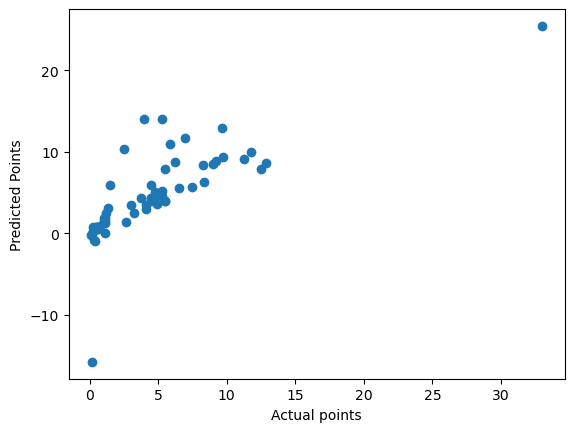

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(y_test, y_pred)
plt.xlabel('Actual points')
plt.ylabel('Predicted Points')
plt.show()

<h2>Saving Model</h2>

In [ ]:
import joblib
joblib.dump(model,"Car Price Prediction.pkl")

['Car Price Prediction.pkl']